# KMeans

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
from sklearn.metrics import silhouette_score

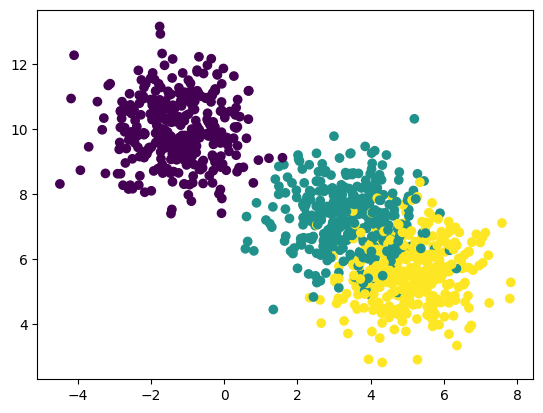

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

plt.scatter(X[:,0],X[:,1],c=y)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

## Elbow method To select K Value
wcss = []
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

wcss

[1600.0,
 406.5327530127477,
 244.2390868192676,
 210.54181345182695,
 164.79524727988047,
 138.08399093097654,
 125.11771055470919,
 116.75417101479593,
 102.36734927915518,
 95.72595254625271]

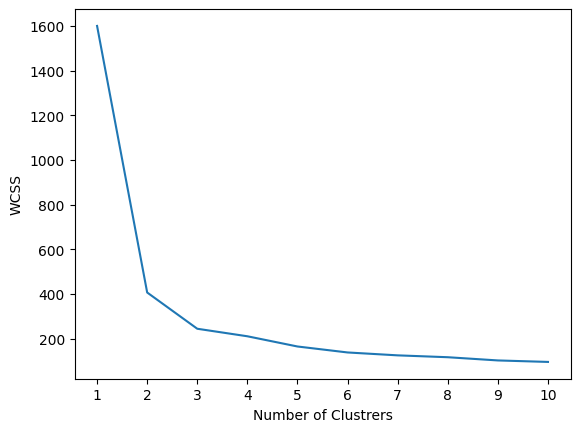

In [6]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3,init="k-means++")
kmeans.fit_predict(X_train_scaled)

y_pred=kmeans.predict(X_test_scaled)
y_pred

array([2, 1, 2, 1, 1, 2, 0, 2, 1, 2, 0, 0, 1, 1, 1, 2, 2, 1, 0, 0, 2, 2,
       2, 1, 0, 2, 1, 2, 2, 0, 2, 0, 2, 2, 0, 1, 1, 0, 0, 1, 2, 0, 2, 2,
       1, 1, 0, 2, 1, 0, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 1, 2, 2, 0, 0, 1,
       2, 0, 2, 2, 0, 0, 0, 2, 1, 0, 1, 2, 1, 0, 0, 0, 1, 2, 2, 1, 1, 1,
       0, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 2, 2, 1, 2,
       1, 0, 2, 1, 0, 1, 2, 0, 0, 1, 0, 2, 0, 2, 1, 2, 2, 2, 1, 0, 0, 2,
       2, 1, 0, 1, 1, 0, 0, 0, 2, 0, 2, 1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2,
       1, 0, 0, 1, 2, 0, 1, 2, 2, 0, 1, 0, 2, 2, 2, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 2, 1, 2, 2, 0, 0, 1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 2, 0, 2, 0,
       2, 0], dtype=int32)

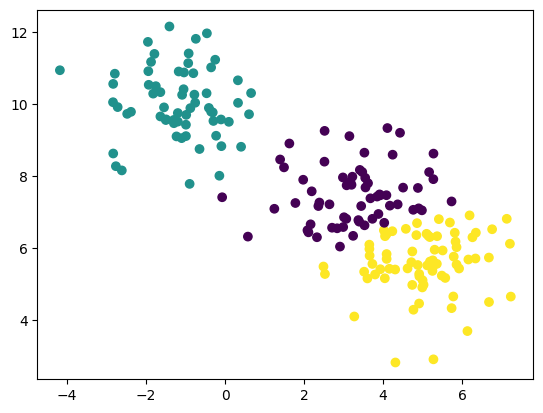

In [8]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [9]:
## Validating the k value
## kneelocator
## Silhoutee scoring
## kneelocator
!pip install kneed


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
kl.elbow

np.int64(2)

In [11]:
## silhoutte score
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)
silhouette_coefficients

[0.6441046410714951,
 0.5049925685079868,
 0.4395919276566424,
 0.35128716871171434,
 0.3421283353333538,
 0.3476505453888407,
 0.32991076943219527,
 0.3245567017254423,
 0.32916123239682576]

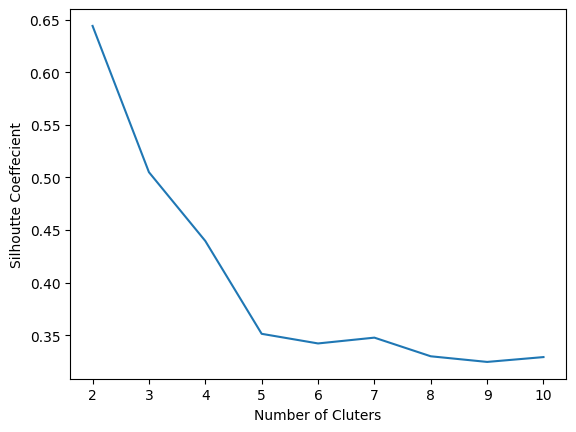

In [12]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()

# Hierarichal

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [3]:
iris=datasets.load_iris()
iris_data = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(iris_data)
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

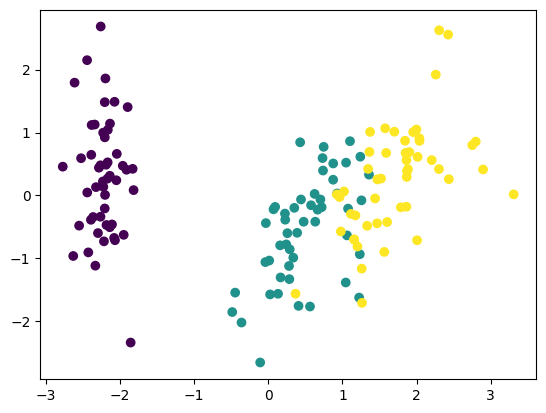

In [5]:
pca = PCA(n_components=2)
pca_scaled = pca.fit_transform(X_scaled)
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=iris.target)

Text(0, 0.5, 'Eucledian Distance')

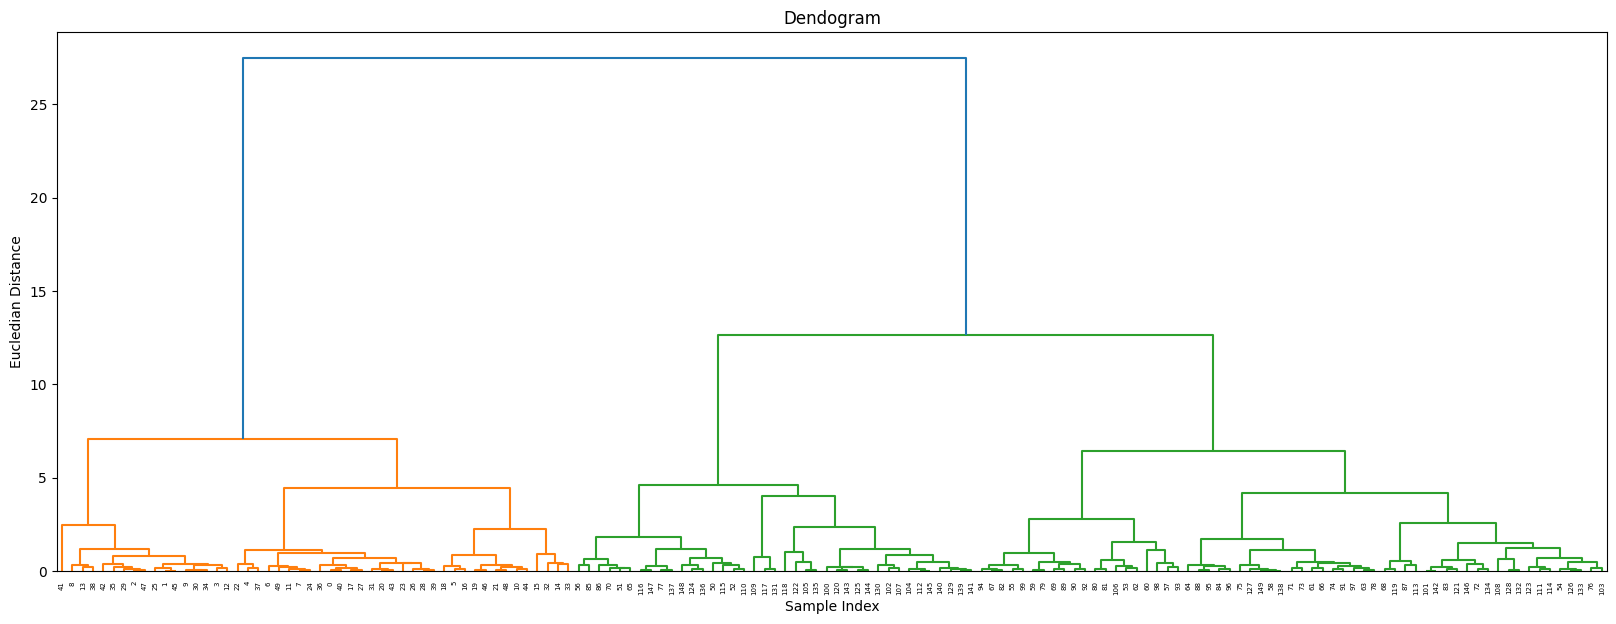

In [6]:
## Agglomerative Clustering
## To construct a dendogram
import scipy.cluster.hierarchy as sc
##plot the dendogram
plt.figure(figsize=(20,7))
plt.title("Dendograms")

## create dendogram
sc.dendrogram(sc.linkage(pca_scaled,method='ward'))
plt.title('Dendogram')
plt.xlabel('Sample Index')
plt.ylabel('Eucledian Distance')

In [8]:
cluster = AgglomerativeClustering(n_clusters=2, linkage='ward')
cluster.fit_predict(pca_scaled)
cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

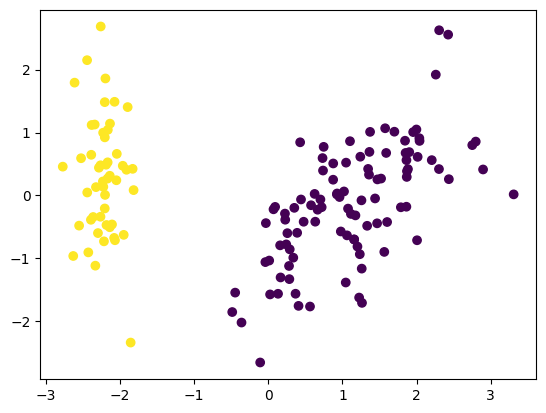

In [9]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=cluster.labels_)

In [10]:
silhouette_coefficients = []
for k in range(2,11):
    agglo = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agglo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,agglo.labels_)
    silhouette_coefficients.append(score)

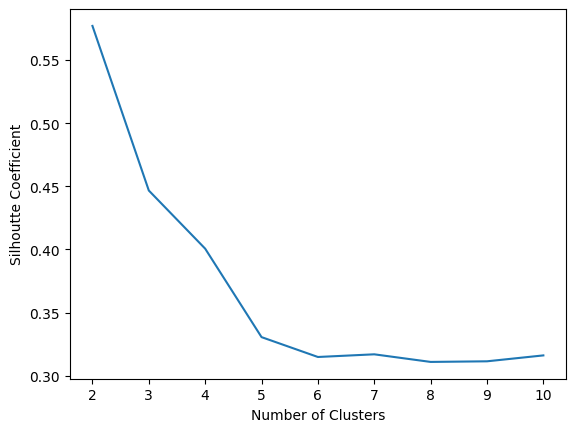

In [11]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte Coefficient")
plt.show()

# DBSCAN

In [12]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline

In [16]:
X,y=make_moons(n_samples=250,noise=0.05)
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 2.51008159e-01, -1.51528422e+00],
       [ 1.40677355e+00, -6.52248819e-01],
       [-1.52160775e+00,  8.96646759e-01],
       [-5.65542357e-01,  2.45568482e-01],
       [ 1.60662288e+00, -6.69020904e-02],
       [ 4.32981625e-01, -1.32890969e+00],
       [ 9.16821056e-01, -1.42610835e+00],
       [-1.67439364e+00, -1.87903527e-01],
       [-5.69721911e-01, -2.51465223e-01],
       [ 3.28824664e-01,  7.87027309e-01],
       [ 5.50837280e-01, -1.67272269e-02],
       [ 6.05680079e-01, -4.19139375e-01],
       [ 4.29695182e-01,  4.98988200e-01],
       [-5.11202623e-01, -1.43328132e-01],
       [-3.71916348e-01,  1.64551197e+00],
       [-9.86965256e-02, -9.16296950e-01],
       [ 9.35258846e-01, -1.49168320e+00],
       [ 3.18525084e-01,  1.02838368e+00],
       [ 5.41685744e-01,  2.62801098e-01],
       [ 1.41134631e+00, -1.08348003e+00],
       [ 3.39508798e-02,  1.28341537e+00],
       [-1.78584165e+00, -4.55679276e-01],
       [ 1.05543448e+00, -1.46853555e+00],
       [-1.

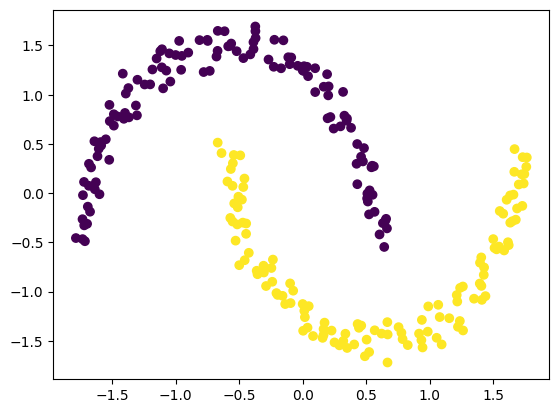

In [17]:
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=y)

In [20]:
dbscan = DBSCAN(eps=0.3)
dbscan.fit(X_scaled)
dbscan.labels_

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 0])

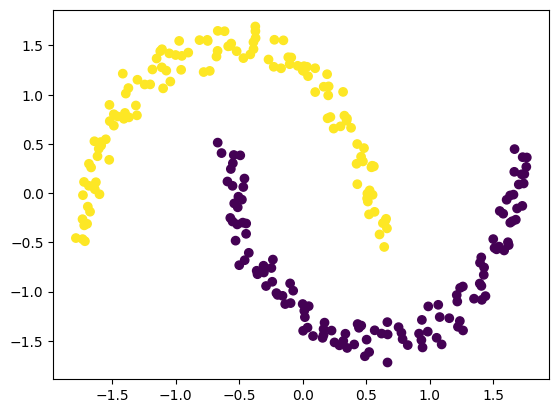

In [21]:
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=dbscan.labels_)